<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_17/2984937731.py:19: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(input_path, sep='\s+', header=None, names=cols)


Dataset Dimensions: (20631, 26)

Training models...
Logistic Regression: Accuracy = 0.7213
Random Forest: Accuracy = 0.7250
KNN: Accuracy = 0.6896
------------------------------
Model Accuracy: 68.96%
------------------------------
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.67      0.74      0.70      1607
     Warning       0.59      0.56      0.57      1500
     Failure       0.89      0.80      0.84      1020

    accuracy                           0.69      4127
   macro avg       0.71      0.70      0.71      4127
weighted avg       0.69      0.69      0.69      4127



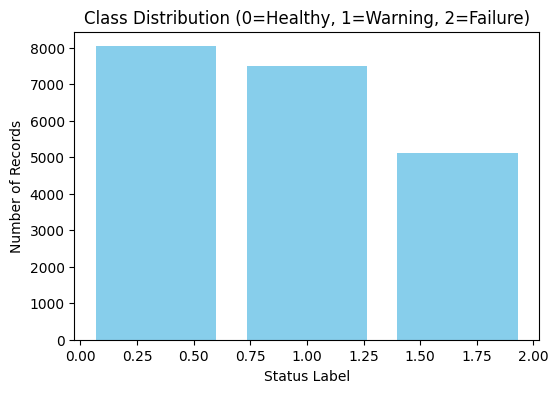

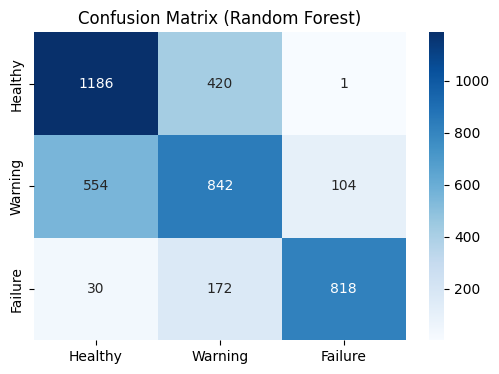

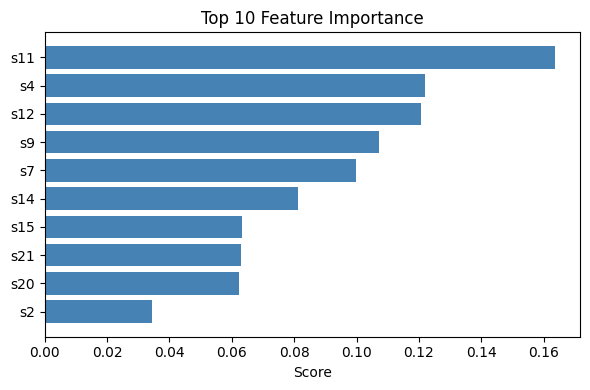

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Task 1: Data Prep & Understanding
# Columns based on documentation
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + ['s' + str(i) for i in range(1, 22)]
input_path = '/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt'
df = pd.read_csv(input_path, sep='\s+', header=None, names=cols)

print(f"Dataset Dimensions: {df.shape}")
df.head()

# RUL

max_cycle_df = df.groupby('unit')['cycle'].max().reset_index()
max_cycle_df.columns = ['unit', 'max_cycle']

df = pd.merge(df, max_cycle_df, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']

# 3. Create Labels (Classification Task)

def categorize_status(rul_value):
    if rul_value <= 50:
        return 2  # Failure (Danger)
    elif rul_value <= 125:
        return 1  # Warning (Be careful)
    else:
        return 0  # Healthy (Normal)

# 4. Feature Selection & Cleaning

df['label'] = df['RUL'].apply(categorize_status)

selected_features = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
X = df[selected_features]
y = df['label']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Task 2: Model Implementation

models = {
    'Logistic Regression': LogisticRegression(max_iter=3000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}
trained_models = {}

print("\nTraining models...")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: Accuracy = {acc:.4f}")
    best_model_name = "Random Forest"
    target_names = ['Healthy', 'Warning', 'Failure']
    
# Task 3: Evaluation & Visualization

predictions = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)

print("-" * 30)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_test, predictions, target_names = ['Healthy', 'Warning', 'Failure']))

# Plot 1: Class Distribution
plt.figure(figsize=(6, 4))
plt.hist(df['label'], bins=3, rwidth=0.8, color='skyblue')
plt.title('Class Distribution (0=Healthy, 1=Warning, 2=Failure)')
plt.xlabel('Status Label')
plt.ylabel('Number of Records')
plt.show()

# Plot 2: Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix ({best_model_name})')

plt.figure(figsize=(6, 4))
rf = trained_models['Random Forest']
importances = rf.feature_importances_

indices = np.argsort(importances)[::-1][:10]

# Plot 3: Feature Importance (only for Random Forest)
plt.barh(range(10), importances[indices][::-1], color='steelblue')
plt.yticks(range(10), [selected_features[i] for i in indices][::-1])
plt.title('Top 10 Feature Importance')
plt.xlabel('Score')

plt.tight_layout()
plt.show()
